# Monte Carlo Portfolio Risk Engine — Demo

This notebook walks through the full simulation pipeline:

1. Fetching real market data from Yahoo Finance
2. Estimating market parameters (drift, covariance)
3. Monte Carlo simulation with trajectory visualization
4. Loss distribution and risk metrics (VaR, ES)
5. Comparing allocation strategies
6. Stress testing with crisis correlations
7. GPU acceleration benchmark (if available)

In [1]:
import time
from datetime import date

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
})

from portfolio_risk_engine.domain.models.asset import Asset
from portfolio_risk_engine.domain.models.market_parameters import MarketParameters
from portfolio_risk_engine.domain.models.portfolio import Portfolio
from portfolio_risk_engine.domain.models.position import Position
from portfolio_risk_engine.domain.models.portfolio_risk_metrics import PortfolioRiskMetrics
from portfolio_risk_engine.domain.value_objects.currency import Currency
from portfolio_risk_engine.domain.value_objects.ticker import Ticker
from portfolio_risk_engine.domain.value_objects.weight import Weight
from portfolio_risk_engine.domain.value_objects.date_range import DateRange
from portfolio_risk_engine.domain.services.cholesky import cholesky
from portfolio_risk_engine.application.use_cases.fetch_market_data import FetchMarketData
from portfolio_risk_engine.application.use_cases.compute_log_returns import ComputeLogReturns
from portfolio_risk_engine.application.use_cases.estimate_market_parameters import EstimateMarketParameters
from portfolio_risk_engine.application.use_cases.run_monte_carlo import RunMonteCarlo
from portfolio_risk_engine.application.use_cases.compute_portfolio_risk import ComputePortfolioRisk
from portfolio_risk_engine.infrastructure.market_data.yahoo_finance_market_data_provider import YahooFinanceMarketDataProvider
from portfolio_risk_engine.infrastructure.simulation.cpu_monte_carlo_engine import CpuMonteCarloEngine

try:
    from portfolio_risk_engine.infrastructure.simulation.gpu_accelerated_pipeline import (
        GpuAcceleratedPipeline,
    )
    _GPU_AVAILABLE = True
except Exception:
    _GPU_AVAILABLE = False

USD = Currency("USD")
SEED = 42

print("Imports OK")
print(f"GPU available: {_GPU_AVAILABLE}")

Imports OK
GPU available: True


---
## 1. Fetch Real Market Data (Yahoo Finance)

We fetch 1 year of historical prices for a 3-asset portfolio:
**AAPL** (Tech), **JPM** (Finance), **XOM** (Energy).

In [2]:
TICKERS = (Ticker("AAPL"), Ticker("JPM"), Ticker("XOM"))
LABELS = ["AAPL", "JPM", "XOM"]
WEIGHTS = (0.50, 0.30, 0.20)

# Portfolio
portfolio = Portfolio(positions=tuple(
    Position(asset=Asset(ticker=t, currency=USD), weight=Weight(w))
    for t, w in zip(TICKERS, WEIGHTS)
))

# Fetch historical prices
provider = YahooFinanceMarketDataProvider()
prices = FetchMarketData(provider).execute(
    tickers=TICKERS,
    date_range=DateRange(start=date(2024, 1, 1), end=date(2025, 1, 1)),
)

print(f"Fetched {len(prices.dates)} trading days")
print(f"Period: {prices.dates[0]} → {prices.dates[-1]}")
for t in TICKERS:
    p = prices.prices_by_ticker[t]
    print(f"  {t.value}: ${p[0]:.2f} → ${p[-1]:.2f}  ({(p[-1]/p[0]-1)*100:+.1f}%)")

Fetched 252 trading days
Period: 2024-01-02 → 2024-12-31
  AAPL: $183.73 → $249.06  (+35.6%)
  JPM: $163.84 → $233.69  (+42.6%)
  XOM: $94.85 → $103.07  (+8.7%)


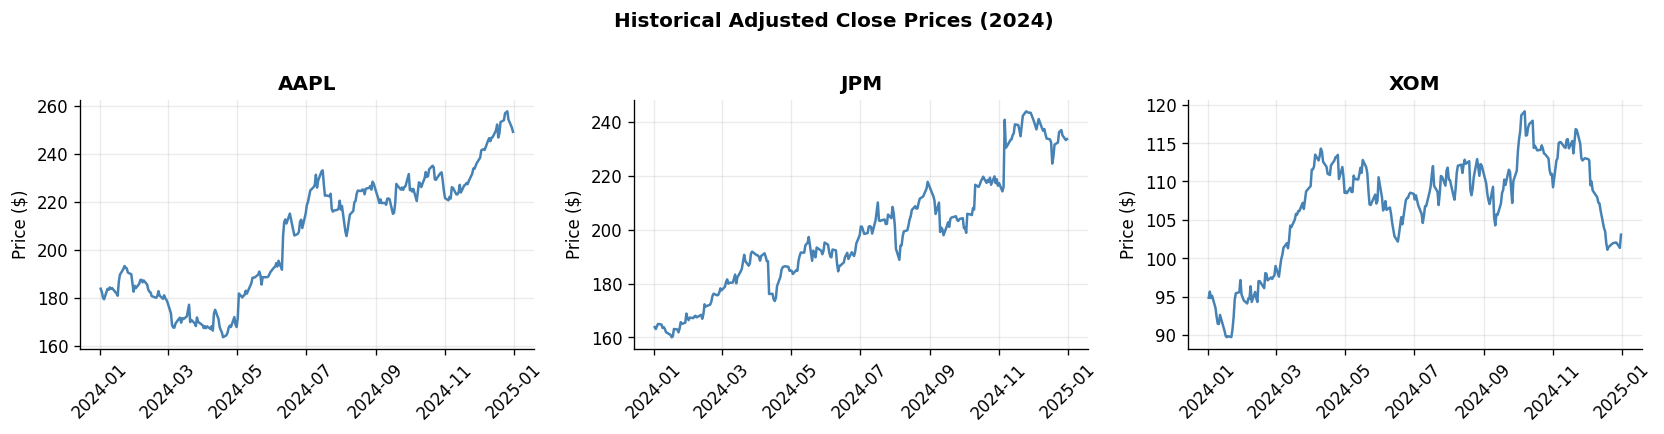

In [3]:
# Plot historical prices
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)

for ax, ticker, label in zip(axes, TICKERS, LABELS):
    p = prices.prices_by_ticker[ticker]
    ax.plot(prices.dates, p, color="steelblue", lw=1.5)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Price ($)")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Historical Adjusted Close Prices (2024)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Estimate Market Parameters

Compute log returns, then estimate annualized drift $\boldsymbol{\mu}$ and covariance $\Sigma$.

In [4]:
returns = ComputeLogReturns.execute(prices)
params = EstimateMarketParameters().execute(returns)

print(f"Annualization factor: {params.annualization_factor}")
print(f"\nAnnualized drift (μ):")
for t, d in zip(params.tickers, params.drift_vector):
    print(f"  {t.value}: {d:+.4f} ({d*100:+.1f}%)")

print(f"\nAnnualized covariance matrix:")
cov = np.array(params.covariance_matrix)
header = "         " + "  ".join(f"{l:>8}" for l in LABELS)
print(header)
for label, row in zip(LABELS, cov):
    vals = "  ".join(f"{v:>8.5f}" for v in row)
    print(f"  {label:>5}  {vals}")

# Extract volatilities and correlation
vols = np.sqrt(np.diag(cov))
corr_matrix = cov / np.outer(vols, vols)
print(f"\nAnnualized volatilities: {', '.join(f'{v:.1%}' for v in vols)}")
print(f"\nCorrelation matrix:")
print(np.round(corr_matrix, 3))

Annualization factor: 252

Annualized drift (μ):
  AAPL: +0.3054 (+30.5%)
  JPM: +0.3565 (+35.6%)
  XOM: +0.0835 (+8.4%)

Annualized covariance matrix:
             AAPL       JPM       XOM
   AAPL   0.04984   0.00094  -0.00065
    JPM   0.00094   0.05450   0.01367
    XOM  -0.00065   0.01367   0.03667

Annualized volatilities: 22.3%, 23.3%, 19.1%

Correlation matrix:
[[ 1.     0.018 -0.015]
 [ 0.018  1.     0.306]
 [-0.015  0.306  1.   ]]


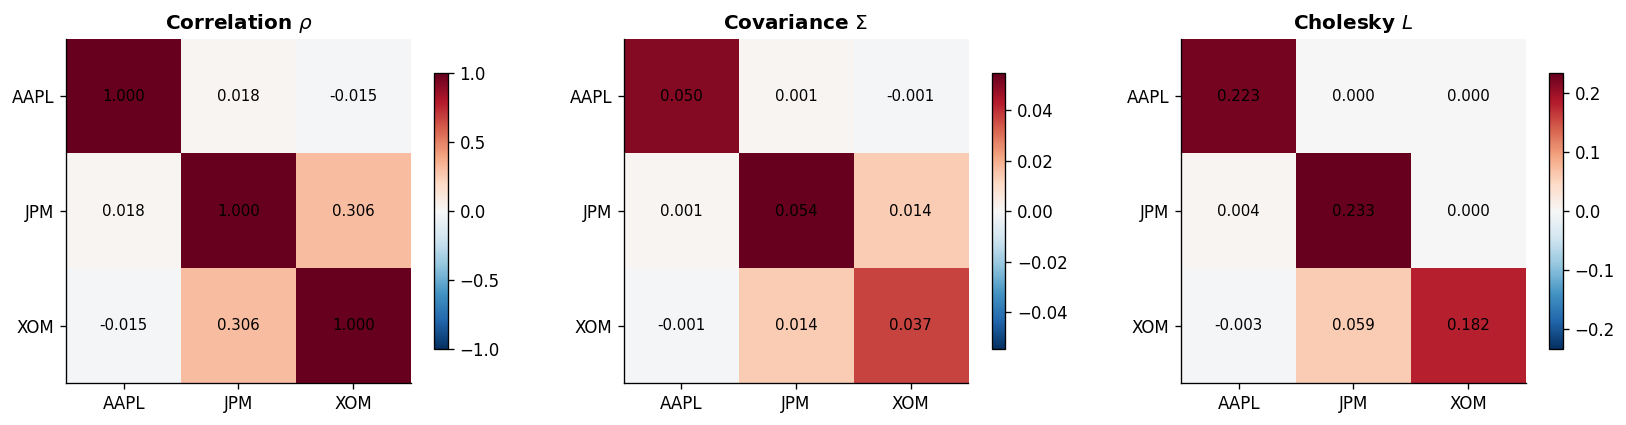

Reconstruction error |L @ L.T - Σ|: 6.94e-18


In [5]:
# Cholesky decomposition visualization
L_tuple = cholesky(params.covariance_matrix)
L = np.array(L_tuple)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, mat, title in zip(
    axes,
    [corr_matrix, cov, L],
    ["Correlation $\\rho$", "Covariance $\\Sigma$", "Cholesky $L$"],
):
    vmax = max(abs(mat.min()), abs(mat.max()))
    im = ax.imshow(mat, vmin=-vmax, vmax=vmax, cmap="RdBu_r")
    ax.set_xticks(range(3))
    ax.set_xticklabels(LABELS)
    ax.set_yticks(range(3))
    ax.set_yticklabels(LABELS)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", fontsize=9)
    ax.set_title(title, fontweight="bold")
    ax.grid(False)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

print(f"Reconstruction error |L @ L.T - Σ|: {np.max(np.abs(L @ L.T - cov)):.2e}")

---
## 3. Monte Carlo Simulation — Price Trajectories

The engine computes **terminal prices** $S_T$ for efficiency. To visualize full trajectories
day-by-day, we simulate GBM paths directly:

$$S_{t+1} = S_t \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sqrt{\Delta t} \cdot L \cdot Z_t\right]$$

This section shows a sample of paths to see the distribution of possible futures.

In [6]:
N_PATHS = 50_000
TIME_HORIZON = 252  # 1 year forward
N_DISPLAY = 200     # paths to display (subset for readability)

n_assets = len(params.tickers)
dt = 1.0 / params.annualization_factor
drift = np.array(params.drift_vector)
variances = np.diag(cov)

# Initial prices = last observed prices
INITIAL_PRICES = tuple(prices.prices_by_ticker[t][-1] for t in params.tickers)
S0 = np.array(INITIAL_PRICES)

print(f"Simulating {N_PATHS:,} paths × {TIME_HORIZON} days × {n_assets} assets")
print(f"Initial prices: {dict(zip(LABELS, [f'${s:.2f}' for s in S0]))}")

# --- Full path simulation (for visualization) ---
rng = np.random.default_rng(SEED)

# drift-adjusted step
drift_step = (drift - 0.5 * variances) * dt  # (n_assets,)
sqrt_dt = np.sqrt(dt)

# Simulate all paths: shape (n_assets, N_PATHS, TIME_HORIZON+1)
t0 = time.perf_counter()

paths = np.zeros((n_assets, N_PATHS, TIME_HORIZON + 1))
paths[:, :, 0] = S0[:, np.newaxis]

for step in range(TIME_HORIZON):
    Z = rng.standard_normal((n_assets, N_PATHS))
    correlated_Z = L @ Z
    log_increment = drift_step[:, np.newaxis] + sqrt_dt * correlated_Z
    paths[:, :, step + 1] = paths[:, :, step] * np.exp(log_increment)

elapsed_paths = time.perf_counter() - t0
print(f"Full path simulation: {elapsed_paths:.2f} s")

Simulating 50,000 paths × 252 days × 3 assets
Initial prices: {'AAPL': '$249.06', 'JPM': '$233.69', 'XOM': '$103.07'}


Full path simulation: 0.61 s


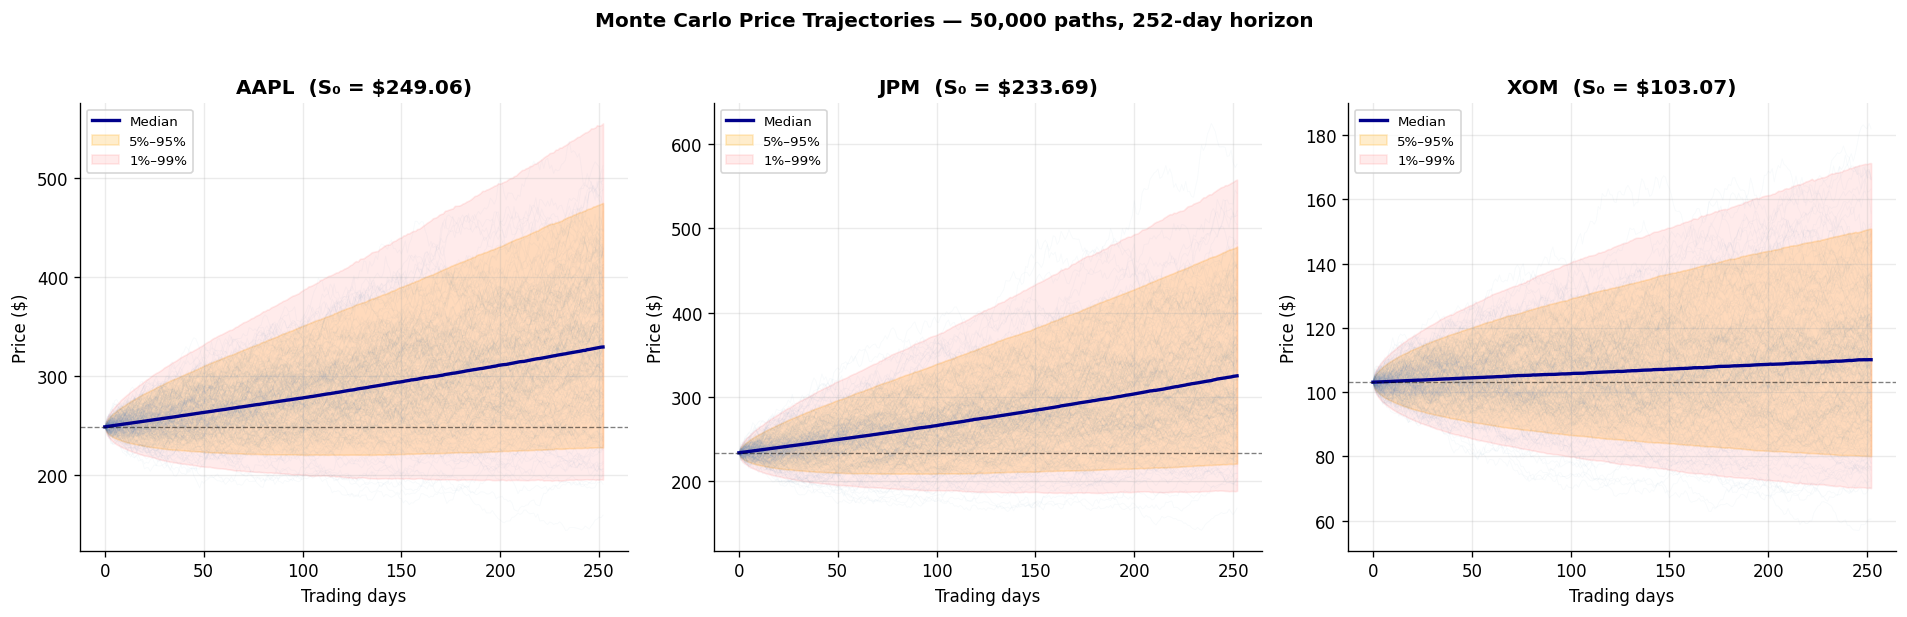

In [7]:
# --- Plot: All trajectories (sample) per asset ---
days = np.arange(TIME_HORIZON + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, i, label in zip(axes, range(n_assets), LABELS):
    # Plot a sample of paths
    for j in range(N_DISPLAY):
        ax.plot(days, paths[i, j, :], color="steelblue", alpha=0.04, lw=0.5)

    # Overlay quantiles
    median_path = np.median(paths[i, :, :], axis=0)
    q05 = np.percentile(paths[i, :, :], 5, axis=0)
    q95 = np.percentile(paths[i, :, :], 95, axis=0)
    q01 = np.percentile(paths[i, :, :], 1, axis=0)
    q99 = np.percentile(paths[i, :, :], 99, axis=0)

    ax.plot(days, median_path, color="darkblue", lw=2, label="Median")
    ax.fill_between(days, q05, q95, color="orange", alpha=0.2, label="5%–95%")
    ax.fill_between(days, q01, q99, color="red", alpha=0.08, label="1%–99%")
    ax.axhline(S0[i], color="black", ls="--", lw=0.8, alpha=0.5)

    ax.set_title(f"{label}  (S₀ = ${S0[i]:.2f})", fontweight="bold")
    ax.set_xlabel("Trading days")
    ax.set_ylabel("Price ($)")
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle(
    f"Monte Carlo Price Trajectories — {N_PATHS:,} paths, {TIME_HORIZON}-day horizon",
    fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

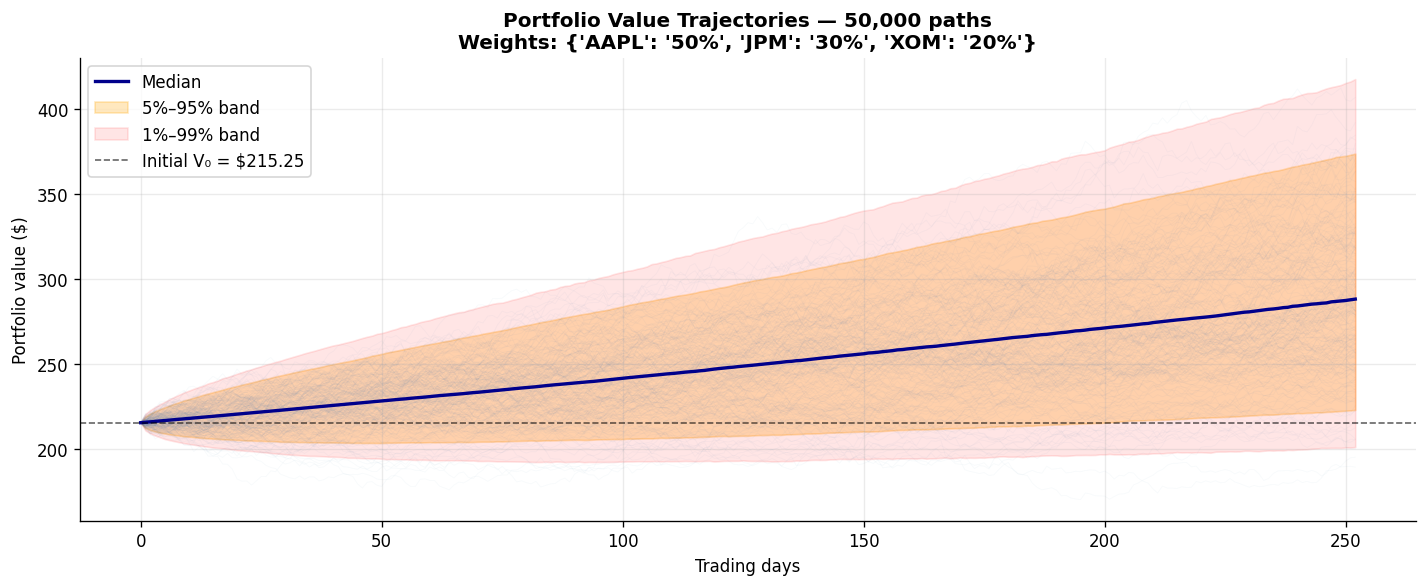

V₀ = $215.25
E[V_T] = $291.69  (+35.5%)
Median V_T = $287.98
5th percentile = $222.78
1st percentile = $200.92


In [8]:
# --- Plot: Portfolio value trajectories ---
weights_arr = np.array(WEIGHTS)  # (n_assets,)

# Weighted portfolio value at each step: sum(w_i * S_i_t)
portfolio_paths = np.zeros((N_PATHS, TIME_HORIZON + 1))
for i in range(n_assets):
    portfolio_paths += weights_arr[i] * paths[i, :, :]

V0 = float(weights_arr @ S0)

fig, ax = plt.subplots(figsize=(12, 5))

# Sample paths
for j in range(N_DISPLAY):
    ax.plot(days, portfolio_paths[j, :], color="steelblue", alpha=0.04, lw=0.5)

# Quantile bands
median_pf = np.median(portfolio_paths, axis=0)
q05_pf = np.percentile(portfolio_paths, 5, axis=0)
q95_pf = np.percentile(portfolio_paths, 95, axis=0)
q01_pf = np.percentile(portfolio_paths, 1, axis=0)
q99_pf = np.percentile(portfolio_paths, 99, axis=0)

ax.plot(days, median_pf, color="darkblue", lw=2, label="Median")
ax.fill_between(days, q05_pf, q95_pf, color="orange", alpha=0.25, label="5%–95% band")
ax.fill_between(days, q01_pf, q99_pf, color="red", alpha=0.1, label="1%–99% band")
ax.axhline(V0, color="black", ls="--", lw=1, alpha=0.6, label=f"Initial V₀ = ${V0:.2f}")

ax.set_title(
    f"Portfolio Value Trajectories — {N_PATHS:,} paths\n"
    f"Weights: {dict(zip(LABELS, [f'{w:.0%}' for w in WEIGHTS]))}",
    fontweight="bold",
)
ax.set_xlabel("Trading days")
ax.set_ylabel("Portfolio value ($)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

VT = portfolio_paths[:, -1]
print(f"V₀ = ${V0:.2f}")
print(f"E[V_T] = ${VT.mean():.2f}  ({(VT.mean()/V0 - 1)*100:+.1f}%)")
print(f"Median V_T = ${np.median(VT):.2f}")
print(f"5th percentile = ${np.percentile(VT, 5):.2f}")
print(f"1st percentile = ${np.percentile(VT, 1):.2f}")

---
## 4. Risk Metrics — Terminal Price Engine

Now we use the **engine** (optimized: only terminal prices, no intermediate steps)
to compute portfolio risk metrics.

In [9]:
engine = CpuMonteCarloEngine(seed=SEED)

t0 = time.perf_counter()
sim = RunMonteCarlo(engine).execute(
    market_params=params,
    initial_prices=INITIAL_PRICES,
    num_simulations=N_PATHS,
    time_horizon_days=TIME_HORIZON,
)
risk = ComputePortfolioRisk.execute(portfolio, sim)
elapsed_engine = time.perf_counter() - t0

print(f"Engine simulation: {elapsed_engine:.3f} s  (vs {elapsed_paths:.2f} s for full paths)")
print(f"\n{'Metric':<20} {'Value':>12}")
print("-" * 35)
print(f"{'Mean return':<20} {risk.mean_return:>+12.4%}")
print(f"{'Volatility':<20} {risk.volatility:>12.4%}")
print(f"{'VaR 95%':<20} {risk.var_95:>12.4%}")
print(f"{'VaR 99%':<20} {risk.var_99:>12.4%}")
print(f"{'ES 95%':<20} {risk.es_95:>12.4%}")
print(f"{'ES 99%':<20} {risk.es_99:>12.4%}")

Engine simulation: 0.007 s  (vs 0.61 s for full paths)

Metric                      Value
-----------------------------------
Mean return             +32.3738%
Volatility               19.7270%
VaR 95%                  -3.0610%
VaR 99%                   6.9203%
ES 95%                    3.0252%
ES 99%                   11.1988%


---
## 5. Loss Distribution

**Convention**: loss = −return. Positive = portfolio lost money.

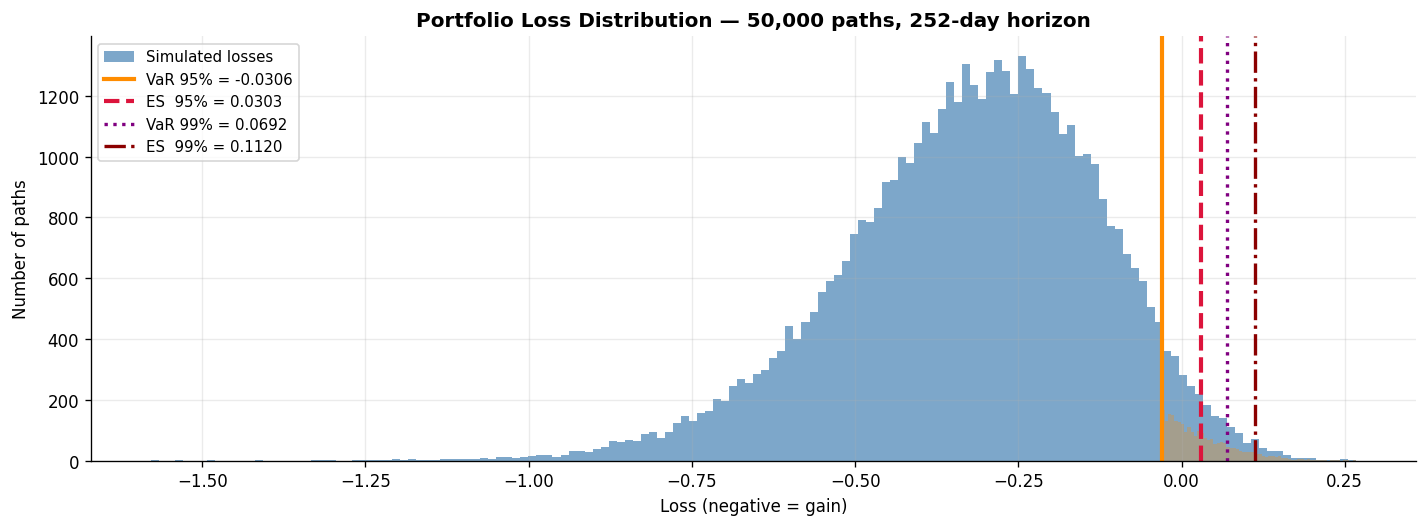

In [10]:
# Reconstruct losses from simulation result
weight_map = dict(zip(portfolio.tickers, portfolio.weights))
s0_map = dict(zip(sim.tickers, sim.initial_prices))

portfolio_returns = np.zeros(sim.num_simulations)
for ticker in sim.tickers:
    w = weight_map[ticker]
    s0 = s0_map[ticker]
    st = np.array(sim.terminal_prices[ticker])
    portfolio_returns += w * (st / s0 - 1.0)

losses = -portfolio_returns

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.hist(losses, bins=150, color="steelblue", alpha=0.7, edgecolor="none", label="Simulated losses")
ax.axvline(risk.var_95, color="darkorange", lw=2.5, label=f"VaR 95% = {risk.var_95:.4f}")
ax.axvline(risk.es_95, color="crimson", lw=2.5, ls="--", label=f"ES  95% = {risk.es_95:.4f}")
ax.axvline(risk.var_99, color="purple", lw=2, ls=":", label=f"VaR 99% = {risk.var_99:.4f}")
ax.axvline(risk.es_99, color="darkred", lw=2, ls="-.", label=f"ES  99% = {risk.es_99:.4f}")

# Shade tail
tail_mask = losses >= risk.var_95
if tail_mask.any():
    h, e = np.histogram(losses[tail_mask], bins=60)
    ax.bar(e[:-1], h, width=np.diff(e), align="edge", color="darkorange", alpha=0.3)

ax.set_xlabel("Loss (negative = gain)")
ax.set_ylabel("Number of paths")
ax.set_title(
    f"Portfolio Loss Distribution — {N_PATHS:,} paths, {TIME_HORIZON}-day horizon",
    fontweight="bold",
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

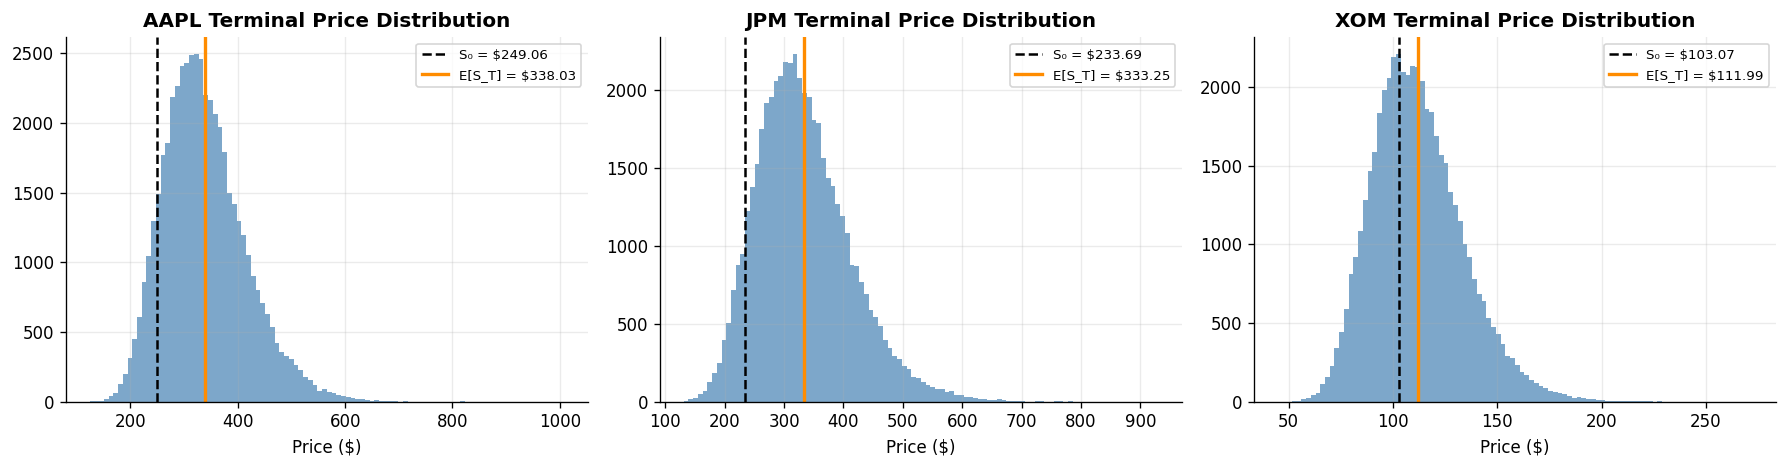

In [11]:
# Terminal price distributions per asset
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ticker, label in zip(axes, sim.tickers, LABELS):
    st = np.array(sim.terminal_prices[ticker])
    s0 = s0_map[ticker]
    ax.hist(st, bins=100, color="steelblue", alpha=0.7, edgecolor="none")
    ax.axvline(s0, color="black", ls="--", lw=1.5, label=f"S₀ = ${s0:.2f}")
    ax.axvline(np.mean(st), color="darkorange", lw=2, label=f"E[S_T] = ${np.mean(st):.2f}")
    ax.set_title(f"{label} Terminal Price Distribution", fontweight="bold")
    ax.set_xlabel("Price ($)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 6. VaR and ES Across Confidence Levels

In [12]:
print(f"{'Confidence':>12}  {'VaR':>10}  {'ES':>10}  {'Tail %':>8}")
print("-" * 46)
for conf in (0.90, 0.95, 0.99):
    v = float(np.percentile(losses, conf * 100))
    e = float(np.mean(losses[losses >= v]))
    tail = 100.0 * float(np.mean(losses > v))
    print(f"{conf*100:>10.0f}%  {v:>10.4f}  {e:>10.4f}  {tail:>7.1f}%")

  Confidence         VaR          ES    Tail %
----------------------------------------------
        90%     -0.0845     -0.0148     10.0%
        95%     -0.0306      0.0303      5.0%
        99%      0.0692      0.1120      1.0%


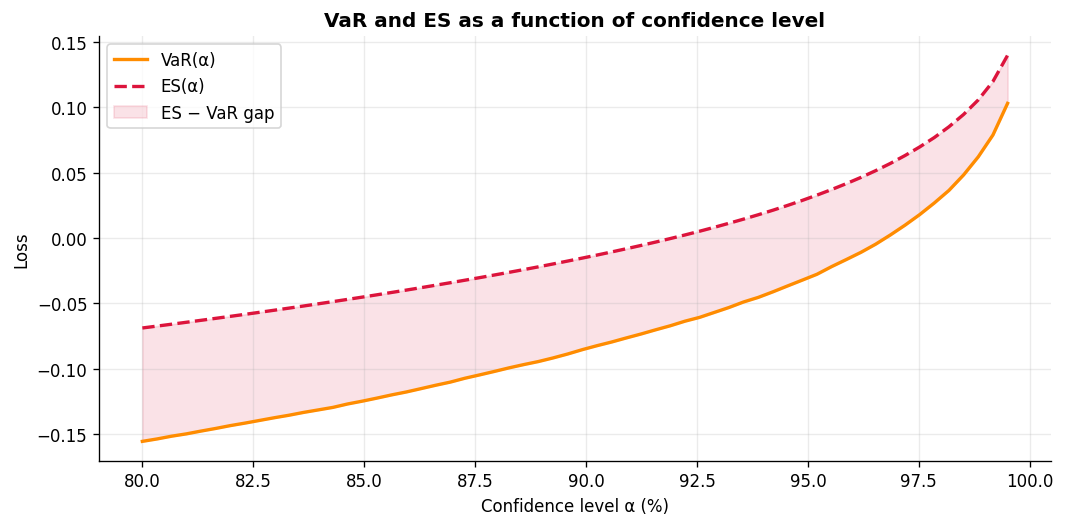

In [13]:
confs = np.linspace(0.80, 0.995, 60)
vars_ = [float(np.percentile(losses, c * 100)) for c in confs]
ess_ = [float(np.mean(losses[losses >= v])) for v in vars_]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(confs * 100, vars_, label="VaR(α)", color="darkorange", lw=2)
ax.plot(confs * 100, ess_, label="ES(α)", color="crimson", lw=2, ls="--")
ax.fill_between(confs * 100, vars_, ess_, alpha=0.12, color="crimson", label="ES − VaR gap")
ax.set_xlabel("Confidence level α (%)")
ax.set_ylabel("Loss")
ax.set_title("VaR and ES as a function of confidence level", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Comparing Allocation Strategies

Same market parameters, different portfolio weights — how does diversification affect tail risk?

In [14]:
def make_portfolio(weights: tuple[float, ...]) -> Portfolio:
    return Portfolio(positions=tuple(
        Position(asset=Asset(ticker=t, currency=USD), weight=Weight(w))
        for t, w in zip(TICKERS, weights)
    ))


def simulate_risk(pf: Portfolio) -> PortfolioRiskMetrics:
    eng = CpuMonteCarloEngine(seed=SEED)
    s = RunMonteCarlo(eng).execute(
        market_params=params, initial_prices=INITIAL_PRICES,
        num_simulations=N_PATHS, time_horizon_days=TIME_HORIZON,
    )
    return ComputePortfolioRisk.execute(pf, s)


strategies = {
    "Concentrated\n(80/10/10)": make_portfolio((0.80, 0.10, 0.10)),
    "Diversified\n(50/30/20)": portfolio,
    "Equal-weight\n(33/33/33)": make_portfolio((1/3, 1/3, 1/3)),
}

rows = {}
print(f"{'Strategy':<25}  {'VaR 95%':>9}  {'ES 95%':>9}  {'Vol':>9}")
print("-" * 58)
for name, pf in strategies.items():
    r = simulate_risk(pf)
    rows[name] = r
    clean = name.replace('\n', ' ')
    print(f"{clean:<25}  {r.var_95:>9.4%}  {r.es_95:>9.4%}  {r.volatility:>9.4%}")

Strategy                     VaR 95%     ES 95%        Vol
----------------------------------------------------------
Concentrated (80/10/10)      2.3906%    9.0990%   25.0739%
Diversified (50/30/20)      -3.0610%    3.0252%   19.7270%
Equal-weight (33/33/33)     -1.4421%    4.0929%   18.2758%


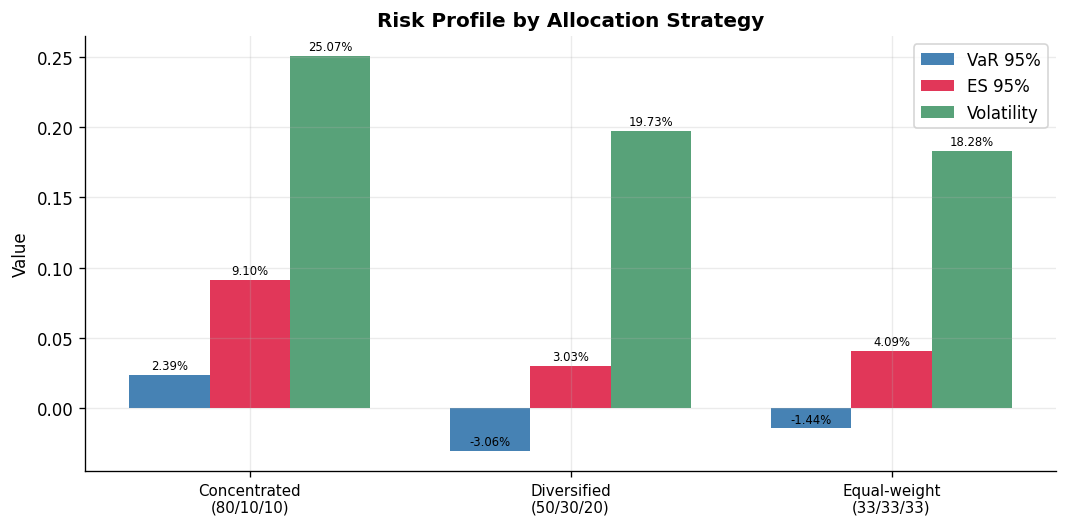

In [15]:
names = list(rows.keys())
vars_s = [rows[n].var_95 for n in names]
ess_s = [rows[n].es_95 for n in names]
vols = [rows[n].volatility for n in names]

x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 4.5))
bars1 = ax.bar(x - w, vars_s, w, label="VaR 95%", color="steelblue")
bars2 = ax.bar(x, ess_s, w, label="ES 95%", color="crimson", alpha=0.85)
bars3 = ax.bar(x + w, vols, w, label="Volatility", color="seagreen", alpha=0.8)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{bar.get_height():.2%}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Value")
ax.set_title("Risk Profile by Allocation Strategy", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Stress Testing — Crisis Correlations

During a market crisis, correlations spike (everything falls together).
We re-run with a stressed correlation matrix.

In [16]:
# Crisis: all correlations jump to 0.85–0.90
corr_stress = np.array([
    [1.00, 0.90, 0.85],
    [0.90, 1.00, 0.88],
    [0.85, 0.88, 1.00],
])
cov_stress = np.outer(vols, vols) * corr_stress
cov_stress_tuple = tuple(tuple(float(x) for x in row) for row in cov_stress)

params_stress = MarketParameters(
    tickers=params.tickers,
    drift_vector=params.drift_vector,
    covariance_matrix=cov_stress_tuple,
    annualization_factor=params.annualization_factor,
)

risk_base = simulate_risk(portfolio)

eng_stress = CpuMonteCarloEngine(seed=SEED)
sim_stress = RunMonteCarlo(eng_stress).execute(
    market_params=params_stress, initial_prices=INITIAL_PRICES,
    num_simulations=N_PATHS, time_horizon_days=TIME_HORIZON,
)
risk_stress = ComputePortfolioRisk.execute(portfolio, sim_stress)

print(f"{'Scenario':<25}  {'VaR 95%':>9}  {'ES 95%':>9}  {'Vol':>9}")
print("-" * 58)
print(f"{'Base':<25}  {risk_base.var_95:>9.4%}  {risk_base.es_95:>9.4%}  {risk_base.volatility:>9.4%}")
print(f"{'Crisis correlations':<25}  {risk_stress.var_95:>9.4%}  {risk_stress.es_95:>9.4%}  {risk_stress.volatility:>9.4%}")

d_var = (risk_stress.var_95 - risk_base.var_95) / abs(risk_base.var_95) if risk_base.var_95 != 0 else 0
d_es = (risk_stress.es_95 - risk_base.es_95) / abs(risk_base.es_95) if risk_base.es_95 != 0 else 0
print(f"\nVaR increase: {d_var:+.1%}")
print(f"ES  increase: {d_es:+.1%}")

Scenario                     VaR 95%     ES 95%        Vol
----------------------------------------------------------
Base                        -3.0610%    3.0252%   19.7270%
Crisis correlations          9.0580%   16.5465%   28.9181%

VaR increase: +395.9%
ES  increase: +447.0%


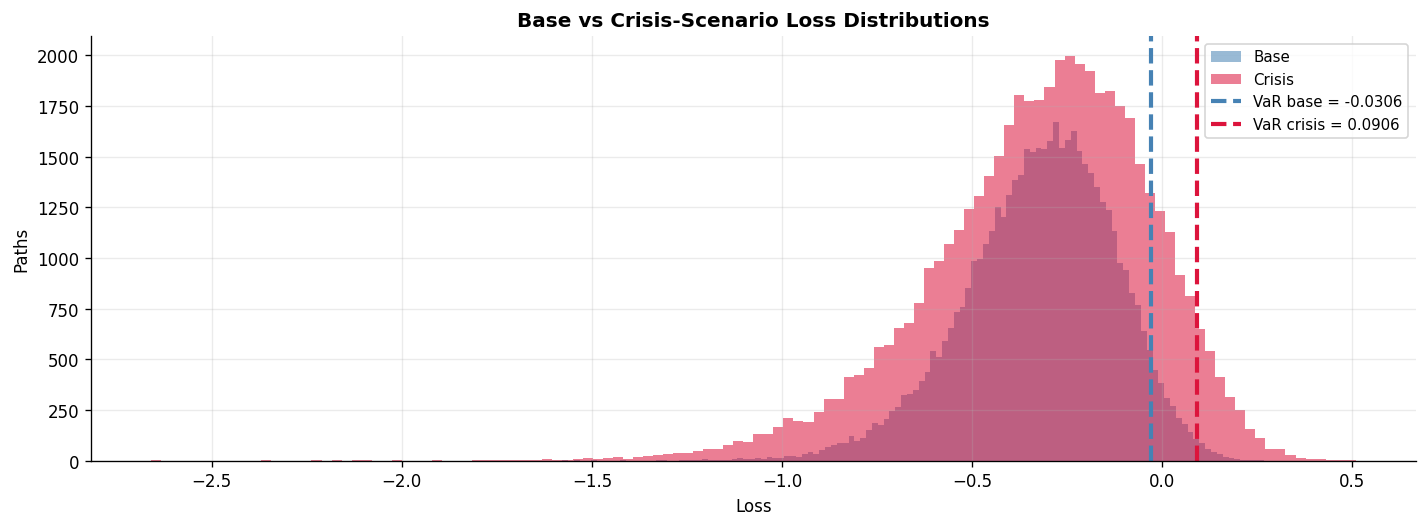

In [17]:
def compute_losses(sim_result, pf):
    wm = dict(zip(pf.tickers, pf.weights))
    sm = dict(zip(sim_result.tickers, sim_result.initial_prices))
    ret = np.zeros(sim_result.num_simulations)
    for t in sim_result.tickers:
        st = np.array(sim_result.terminal_prices[t])
        ret += wm[t] * (st / sm[t] - 1.0)
    return -ret

losses_base = compute_losses(sim, portfolio)
losses_stress = compute_losses(sim_stress, portfolio)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.hist(losses_base, bins=120, alpha=0.55, color="steelblue", label="Base")
ax.hist(losses_stress, bins=120, alpha=0.55, color="crimson", label="Crisis")
ax.axvline(risk_base.var_95, color="steelblue", lw=2.5, ls="--",
           label=f"VaR base = {risk_base.var_95:.4f}")
ax.axvline(risk_stress.var_95, color="crimson", lw=2.5, ls="--",
           label=f"VaR crisis = {risk_stress.var_95:.4f}")
ax.set_xlabel("Loss")
ax.set_ylabel("Paths")
ax.set_title("Base vs Crisis-Scenario Loss Distributions", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. GPU Benchmark

The `GpuAcceleratedPipeline` fuses simulation and risk on GPU.
Only 6 scalar floats are transferred back to CPU.

In [18]:
if not _GPU_AVAILABLE:
    print("GPU not available — skipping.")
    print("Install CuPy: pip install cupy-cuda12x")
else:
    N_BENCH = 100_000
    w_tuple = tuple(portfolio.weights)

    # CPU
    cpu_eng = CpuMonteCarloEngine(seed=SEED)
    t0 = time.perf_counter()
    cpu_sim = RunMonteCarlo(cpu_eng).execute(
        market_params=params, initial_prices=INITIAL_PRICES,
        num_simulations=N_BENCH, time_horizon_days=TIME_HORIZON,
    )
    cpu_risk = ComputePortfolioRisk.execute(portfolio, cpu_sim)
    cpu_time = time.perf_counter() - t0

    # GPU (warm-up + timed)
    pipeline = GpuAcceleratedPipeline(seed=SEED)
    pipeline.run(
        market_params=params, initial_prices=INITIAL_PRICES,
        weights=w_tuple, num_simulations=1_000, time_horizon_days=TIME_HORIZON,
    )

    import cupy as cp
    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    gpu_risk = pipeline.run(
        market_params=params, initial_prices=INITIAL_PRICES,
        weights=w_tuple, num_simulations=N_BENCH, time_horizon_days=TIME_HORIZON,
    )
    cp.cuda.Stream.null.synchronize()
    gpu_time = time.perf_counter() - t0

    speedup = cpu_time / gpu_time

    print(f"{'':12} {'CPU':>12}  {'GPU':>12}")
    print("-" * 40)
    print(f"{'VaR 95%':<12} {cpu_risk.var_95:>12.4%}  {gpu_risk.var_95:>12.4%}")
    print(f"{'ES  95%':<12} {cpu_risk.es_95:>12.4%}  {gpu_risk.es_95:>12.4%}")
    print(f"{'Time (s)':<12} {cpu_time:>12.4f}  {gpu_time:>12.4f}")
    print(f"{'Speedup':<12} {'—':>12}  {speedup:>11.1f}x")

                      CPU           GPU
----------------------------------------
VaR 95%          -2.7873%      -3.0780%
ES  95%           3.0133%       2.8283%
Time (s)           0.0135        0.0261
Speedup                 —          0.5x


---
## Summary

```
Pipeline:  Yahoo Finance → Log Returns → Market Parameters → Monte Carlo → Risk Metrics

Backends:  CpuMonteCarloEngine (NumPy)  |  GpuAcceleratedPipeline (CuPy, fused)

Metrics:   VaR 95/99%, ES 95/99%, mean return, volatility
```

Switching backend:
```python
engine = CpuMonteCarloEngine(seed=42)      # NumPy
engine = GpuMonteCarloEngine(seed=42)      # CuPy — identical interface
```